In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  MissionCtrl — Colab Configuration (Form Fields)               ║
# ║  Adjust these values, then run the cell.                       ║
# ╚══════════════════════════════════════════════════════════════════╝

# @title ⚙️ Configuration { display-mode: "form" }

import os

# @markdown --- Model ---
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # @param ["Qwen/Qwen2.5-0.5B-Instruct", "unsloth/Llama-3.2-3B-Instruct", "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"]
MAX_SEQ_LENGTH = 2048  # @param {type:"integer"}

# @markdown --- Training ---
BATCH_SIZE = 4  # @param {type:"integer"}
NUM_GENERATIONS = 4  # @param {type:"integer"}
LEARNING_RATE = 5e-5  # @param {type:"number"}

# @markdown --- HF Hub ---
HF_REPO = "Jit-fnc/missionctrl_env"  # @param {type:"string"}
PUSH_TO_HUB = True  # @param {type:"boolean"}

# @markdown --- Paths ---
REPO_URL = "https://github.com/Fnc-Jit/MissionCtrl.git"  # @param {type:"string"}
MOUNT_DRIVE = True  # @param {type:"boolean"}

# ── Apply configuration ────────────────────────────────────────────────────
os.environ["MISSIONCTRL_MODEL_NAME"] = MODEL_NAME
os.environ["MISSIONCTRL_REPO_URL"] = REPO_URL
os.environ["MOUNT_DRIVE"] = "1" if MOUNT_DRIVE else "0"
os.environ["MISSIONCTRL_LEARNING_RATE"] = str(LEARNING_RATE)
if not PUSH_TO_HUB:
    os.environ["MISSIONCTRL_NO_PUSH"] = "1"

print("✅ Configuration set:")
print(f"   Model: {MODEL_NAME}")
print(f"   HF Repo: {HF_REPO}")
print(f"   Push to Hub: {PUSH_TO_HUB}")
print(f"   Drive mount: {MOUNT_DRIVE}")
print(f"   Batch size: {BATCH_SIZE}, Generations: {NUM_GENERATIONS}")


✅ Configuration set:
   Model: Qwen/Qwen2.5-0.5B-Instruct
   HF Repo: Jit-fnc/missionctrl_env
   Push to Hub: True
   Drive mount: True
   Batch size: 4, Generations: 4


In [2]:
# ── Install dependencies (Google Colab) ────────────────────────────────────────
# Use sys.executable so packages land in *this* kernel (plain !pip can target another Python).
# Order: generic stack first, then Unsloth, then unsloth_zoo last (pip resolver won’t strip it).

import subprocess
import sys


def pip(*args: str) -> None:
    cmd = [sys.executable, "-m", "pip", *args]
    print(" ", " ".join(cmd))
    subprocess.check_call(cmd)


pip("install", "-q", "trl", "openenv", "transformers", "datasets", "accelerate", "matplotlib")
pip("install", "-q", "--upgrade", "bitsandbytes", "huggingface_hub")

pip(
    "install",
    "-q",
    "unsloth[colab-new]@git+https://github.com/unslothai/unsloth.git",
)
pip("install", "-q", "-U", "unsloth_zoo>=2026.4.8")

import importlib.metadata as _im

try:
    _z = _im.version("unsloth_zoo")
except _im.PackageNotFoundError:
    print("⚠️  PyPI metadata missing; installing unsloth_zoo from GitHub…")
    pip("install", "-q", "-U", "git+https://github.com/unslothai/unsloth-zoo.git")
    _z = _im.version("unsloth_zoo")

print(f"✅ unsloth_zoo {_z} (importlib metadata OK)")

import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("✅ Dependencies installed.")
print("   If a later cell still errors on unsloth, use: Runtime → Restart session, then re-run this cell.")


  /usr/bin/python3 -m pip install -q trl openenv transformers datasets accelerate matplotlib
  /usr/bin/python3 -m pip install -q --upgrade bitsandbytes huggingface_hub
  /usr/bin/python3 -m pip install -q unsloth[colab-new]@git+https://github.com/unslothai/unsloth.git
  /usr/bin/python3 -m pip install -q -U unsloth_zoo>=2026.4.8
✅ unsloth_zoo 2026.4.9 (importlib metadata OK)
✅ Dependencies installed.
   If a later cell still errors on unsloth, use: Runtime → Restart session, then re-run this cell.


In [3]:
# ── Optional: Mount Google Drive for persistent checkpoints ────────────────────
# If MOUNT_DRIVE=True (set in Cell 0), this mounts Drive so checkpoints survive
# Colab session disconnects. Skip this cell to use ephemeral /content storage.

import os
from google.colab import drive

_mount = os.environ.get("MOUNT_DRIVE", "").lower() in ("true", "1", "yes")

if not _mount:
    print("⏭️  Drive mount skipped (MOUNT_DRIVE=False). Using /content for checkpoints.")
    print("   Set MOUNT_DRIVE=True in Cell 0 to enable persistent storage.")
    DRIVE_CHECKPOINT_DIR = "/content/missionctrl_checkpoints"
    os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
else:
    drive.mount('/content/drive')
    DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/missionctrl_checkpoints"
    os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
    print(f"✅ Drive mounted. Checkpoints will be saved to: {DRIVE_CHECKPOINT_DIR}")

os.environ["MISSIONCTRL_CHECKPOINT_DIR"] = DRIVE_CHECKPOINT_DIR
os.environ["MISSIONCTRL_OUTPUT_DIR"] = DRIVE_CHECKPOINT_DIR

if not _mount:
    print(f"✅ Checkpoint dir: {DRIVE_CHECKPOINT_DIR}")


Mounted at /content/drive
✅ Drive mounted. Checkpoints will be saved to: /content/drive/MyDrive/missionctrl_checkpoints


In [4]:
# ── Clone (if needed) + verify MissionCtrl project files ────────────────────────
# 1) Same folder as the notebook; 2) /content/ (working dir); 3) then git clone.
# Set REPO_URL in Cell 0 to override the default public repo.
import os, subprocess, sys

REQUIRED = [
    "train.py",
    "environment.py",
    "reward_model.py",
    "grpo_rewards.py",
    "grpo_completion.py",
]
REPO_DIR = "MissionCtrl"
REPO_URL = (
    os.environ.get("MISSIONCTRL_REPO_URL", "https://github.com/Leo-Expose/MissionCtrl.git").strip()
    or "https://github.com/Leo-Expose/MissionCtrl.git"
)


def all_here() -> bool:
    return all(os.path.isfile(f) for f in REQUIRED)


def all_here_in(d: str) -> bool:
    return all(os.path.isfile(os.path.join(d, f)) for f in REQUIRED)


def missing_in_dir(d: str) -> list:
    return [f for f in REQUIRED if not os.path.isfile(os.path.join(d, f))]


# ── Colab: working directory is always /content ──────────────────────────────
os.chdir("/content")

if all_here():
    print("✅ MissionCtrl files already in /content. Skipping git clone.")
else:
    in_repo = os.path.isdir(REPO_DIR) and all_here_in(REPO_DIR)
    if in_repo:
        os.chdir(os.path.join("/content", REPO_DIR))
        print(f"✅ Using cloned repo at /content/{REPO_DIR}")
    elif os.path.isdir(REPO_DIR):
        _miss = ", ".join(missing_in_dir(REPO_DIR)) or "(unknown)"
        import shutil
        shutil.rmtree(REPO_DIR, ignore_errors=True)
        print(f"⚠️  Incomplete repo removed (was missing: {_miss}). Re-cloning...")

    if not all_here():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
            check=True,
        )
        os.chdir(os.path.join("/content", REPO_DIR))

    if not all_here():
        _miss = ", ".join(missing_in_dir(".")) or ", ".join(REQUIRED)
        raise FileNotFoundError(
            f"Could not find train.py and env modules (missing: {_miss}). "
            f"Set REPO_URL in Cell 0 to a valid git URL."
        )

for f in REQUIRED:
    print("  ✅", f)
print("  cwd:", os.getcwd())

_repo_root = os.path.abspath(".")
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)
    print(f"  Added to sys.path: {_repo_root}")


  ✅ train.py
  ✅ environment.py
  ✅ reward_model.py
  ✅ grpo_rewards.py
  ✅ grpo_completion.py
  cwd: /content/MissionCtrl
  Added to sys.path: /content/MissionCtrl


In [5]:
# ── Verify GPU ──────────────────────────────────────────────────────────────────
import torch

assert torch.cuda.is_available(), (
    "❌ No GPU detected!\n"
    "   Go to Runtime → Change runtime type → Select 'T4 GPU' (or better).\n"
    "   Then restart the session and re-run all cells."
)

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
n_gpu = torch.cuda.device_count()

print(f"🖥️  GPU: {gpu_name}")
print(f"💾 VRAM: {vram_gb:.1f} GB")
print(f"🔢 GPU count: {n_gpu}")

gpu_type = "unknown"
if "T4" in gpu_name:
    gpu_type = "T4"
    print(f"\n💡 Colab T4 detected ({vram_gb:.0f} GB VRAM)")
    print("   • Default curriculum should work with 0.5B model")
    print("   • For 3B+ models, set MISSIONCTRL_T4_CURRICULUM=1 for shorter phases")
    print("   • Consider upgrading to Colab Pro for V100/A100 if training 8B")
elif "V100" in gpu_name:
    gpu_type = "V100"
    print(f"\n✅ Colab V100 detected ({vram_gb:.0f} GB VRAM) — great for training!")
elif "A100" in gpu_name:
    gpu_type = "A100"
    print(f"\n🚀 Colab A100 detected ({vram_gb:.0f} GB VRAM) — excellent for large models!")
elif "L4" in gpu_name:
    gpu_type = "L4"
    print(f"\n✅ Colab L4 detected ({vram_gb:.0f} GB VRAM) — good for 0.5B-3B models")
else:
    print(f"\n⚠️  Unknown GPU type: {gpu_name} ({vram_gb:.0f} GB)")

if n_gpu >= 2:
    print(f"\n✅ {n_gpu} GPUs detected — shorter curriculum; single-device GRPO generation")
elif vram_gb < 20:
    print(f"\n⚠️  Low VRAM ({vram_gb:.0f} GB) — use 0.5B model, or set MISSIONCTRL_T4_CURRICULUM=1")

print("\n✅ GPU verified")


🖥️  GPU: Tesla T4
💾 VRAM: 15.6 GB
🔢 GPU count: 1

💡 Colab T4 detected (16 GB VRAM)
   • Default curriculum should work with 0.5B model
   • For 3B+ models, set MISSIONCTRL_T4_CURRICULUM=1 for shorter phases
   • Consider upgrading to Colab Pro for V100/A100 if training 8B

⚠️  Low VRAM (16 GB) — use 0.5B model, or set MISSIONCTRL_T4_CURRICULUM=1

✅ GPU verified


In [6]:
# ── Smoke-test the environment ──────────────────────────────────────────────────
from environment import MissionCtrlEnv, OverseerAction, parse_action
from reward_model import compute_reward, reward_breakdown

print('--- Smoke test: medium difficulty, 3 tasks ---')
env = MissionCtrlEnv(difficulty='medium', num_tasks=3, seed=42)
obs, info = env.reset()

print(f'  Tasks loaded: {len(obs["task_board"])}')
print(f'  Agent messages: {len(obs["recent_messages"])}')

first_task = obs['task_board'][0]['task_id']
action = OverseerAction('FLAG', task_id=first_task, evidence='fabricated citation detected in prior output')
obs2, reward, terminated, truncated, info = env.step(action)
print(f'  Step reward: {reward:.3f}')
print(f'  Info: {info}')

breakdown = reward_breakdown(env)
print(f'  Reward breakdown: {breakdown["signals"]}')
print(f'  Theoretical ceiling: {breakdown["theoretical_ceiling"]}')

print()
print('--- Smoke test: special difficulty (new tier) ---')
env_special = MissionCtrlEnv(difficulty='special', num_tasks=5, seed=99)
obs_s, _ = env_special.reset()
print(f'  Special tier tasks: {len(obs_s["task_board"])}')

print()
print('--- Smoke test: action parser ---')
test_cases = [
    ('FLAG(T001, "fabricated citation in reference list")', 'FLAG'),
    ('APPROVE(T002)', 'APPROVE'),
    ('SYNTHESIZE_REPORT()', 'SYNTHESIZE'),
    ('garbage output no action', 'NOOP'),
]
for text, expected in test_cases:
    parsed = parse_action(text)
    status = '✅' if parsed.action_type == expected else f'❌ expected {expected}'
    print(f'  {status} "{text[:40]}..." → {parsed.action_type}')

print()
print('✅ Environment smoke test passed')


--- Smoke test: medium difficulty, 3 tasks ---
  Tasks loaded: 3
  Agent messages: 3
  Step reward: 0.055
  Info: {'injected_count': 2, 'caught_count': 0, 'false_positive_count': 1, 'detection_rate': 0.0, 'false_positive_rate': 1.0, 'tasks_done': 0, 'tasks_total': 3, 'step': 1}
  Reward breakdown: {'task_completion': {'raw': 0.0, 'weighted': 0.0}, 'hallucination_detection': {'raw': 0.0, 'weighted': 0.0}, 'false_positive_penalty': {'raw': 1.0, 'weighted': -0.15}, 'delegation_efficiency': {'raw': 1.0, 'weighted': 0.15}, 'llm_judge': {'raw': 0.55, 'weighted': 0.055}}
  Theoretical ceiling: 0.85

--- Smoke test: special difficulty (new tier) ---
  Special tier tasks: 5

--- Smoke test: action parser ---
  ✅ "FLAG(T001, "fabricated citation in refer..." → FLAG
  ✅ "APPROVE(T002)..." → APPROVE
  ✅ "SYNTHESIZE_REPORT()..." → SYNTHESIZE
  ✅ "garbage output no action..." → NOOP

✅ Environment smoke test passed


In [7]:
# ── Run pre-training baseline ──────────────────────────────────────────────────
# FIX #3/#4: baseline now uses final reward (not accumulated sum or per-task overwrite)
from train import run_baseline

baseline_reward = run_baseline()
print(f'\n🎯 Baseline established: {baseline_reward:.3f}')
print(f'Reward ceiling: 0.85 | Training target: 0.68+')
print(f'Baseline is {baseline_reward/0.85*100:.0f}% of theoretical ceiling')


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
📊 Running pre-training baseline (approve-everything strategy)...
  Ep  0: reward=0.355 | detected 0/1 hallucinations
  Ep  1: reward=0.205 | detected 0/3 hallucinations
  Ep  2: reward=0.280 | detected 0/2 hallucinations
  Ep  3: reward=0.130 | detected 0/4 hallucinations
  Ep  4: reward=0.205 | detected 0/3 hallucinations
  Ep  5: reward=0.355 | detected 0/1 hallucinations
  Ep  6: reward=0.280 | detected 0/2 hallucinations
  Ep  7: reward=0.130 | detected 0/4 hallucinations
  Ep  8: reward=0.205 | detected 0/3 hallucinations
  Ep  9: reward=0.205 | detected 0/3 hallucinations
  Ep 10: reward=0.205 | detected 0/3 hallucinations
  Ep 11: reward=0.280 | detected 0/2 hallucinations
  Ep 12: reward=0.280 | detected 0/2 hallucinations
  Ep 13: reward=0.355 | detected 0/1 hallucinations
  Ep 14: reward=0.205 | detected 0/3 hallucinations
  Ep 15: reward=0

In [8]:
# ── Set HuggingFace credentials (Colab) ──────────────────────────────────────────
import os

token = None

try:
    from google.colab import userdata
    token = userdata.get('HF_TOKEN')
    if token:
        print('✅ Found HF_TOKEN in Colab Secrets')
except (ImportError, Exception):
    pass

if not token and os.environ.get('HF_TOKEN'):
    token = os.environ['HF_TOKEN']
    print('✅ Found HF_TOKEN in environment variables')

if not token:
    print('⚠️  No HF_TOKEN found in Secrets or environment.')
    print('   Opening interactive login...')

from huggingface_hub import login

if token:
    login(token=token)
    print('✅ Logged in to HuggingFace')
else:
    login()
    print('✅ Logged in interactively')

import train

try:
    train.HF_REPO = HF_REPO
except NameError:
    train.HF_REPO = 'Proliferation/missionctrl_env'

if 'your-hf' in train.HF_REPO.lower() or 'changeme' in train.HF_REPO.lower():
    raise ValueError(
        '❌ Please update HF_REPO in Cell 0 with your actual HuggingFace username/repo!\n'
        '   Example: train.HF_REPO = "your-username/missionctrl_env"'
    )

try:
    train.BATCH_SIZE = int(BATCH_SIZE)
    train.NUM_GENERATIONS = min(int(NUM_GENERATIONS), int(BATCH_SIZE))
    train.LEARNING_RATE = float(LEARNING_RATE)
    train.MAX_SEQ_LEN = int(MAX_SEQ_LENGTH)
except NameError:
    pass

print(f'✅ Will push trained adapter to: {train.HF_REPO}')
print(f'   GRPO batch_size={train.BATCH_SIZE}, num_generations={train.NUM_GENERATIONS}, max_seq_len={train.MAX_SEQ_LEN}')

print()
print('⚠️  IMPORTANT: Before training, confirm the hackathon evaluation invokes')
print('   your HF-hosted model (not a fixed Groq/API endpoint).')
print('   If evaluators run client.py with their own API_BASE_URL, fine-tuning')
print('   will not affect your score. Check the OpenEnv evaluation spec first.')


⚠️  No HF_TOKEN found in Secrets or environment.
   Opening interactive login...


✅ Logged in interactively
✅ Will push trained adapter to: Jit-fnc/missionctrl_env
   GRPO batch_size=4, num_generations=4, max_seq_len=2048

⚠️  IMPORTANT: Before training, confirm the hackathon evaluation invokes
   your HF-hosted model (not a fixed Groq/API endpoint).
   If evaluators run client.py with their own API_BASE_URL, fine-tuning
   will not affect your score. Check the OpenEnv evaluation spec first.


In [9]:
# ── Override checkpoint directory for Colab ──────────────────────────────────────
import train, os

checkpoint_dir = os.environ.get(
    "MISSIONCTRL_CHECKPOINT_DIR",
    os.environ.get("MISSIONCTRL_OUTPUT_DIR", "/content/missionctrl_checkpoints"),
)
os.makedirs(checkpoint_dir, exist_ok=True)

if hasattr(train, 'OUTPUT_DIR'):
    old_dir = train.OUTPUT_DIR
    train.OUTPUT_DIR = checkpoint_dir
    print(f"✅ Patched train.OUTPUT_DIR: {old_dir} → {checkpoint_dir}")
else:
    train.OUTPUT_DIR = checkpoint_dir
    print(f"✅ Set train.OUTPUT_DIR = {checkpoint_dir}")

os.environ["MISSIONCTRL_OUTPUT_DIR"] = checkpoint_dir
os.environ["MISSIONCTRL_CHECKPOINT_DIR"] = checkpoint_dir

print(f"   Checkpoints will be saved to: {checkpoint_dir}")


✅ Patched train.OUTPUT_DIR: /content/drive/MyDrive/missionctrl_checkpoints → /content/drive/MyDrive/missionctrl_checkpoints
   Checkpoints will be saved to: /content/drive/MyDrive/missionctrl_checkpoints


In [10]:
# ── TRAIN ──────────────────────────────────────────────────────────────────────────
# Full 3-phase curriculum with reward-gated advancement.
#
# Key fixes active in this run:
#   - NUM_GENERATIONS ≤ BATCH_SIZE (no crash) — FIX #2
#   - Full episode rollout in reward fn (meaningful GRPO signal) — FIX #1
#   - max_prompt_length set (seed tag won't be truncated) — FIX #22
#   - padding_side='left' (correct batched generation) — FIX #11
#   - Greedy eval (do_sample=False) for reproducible metrics — FIX #23
#
# Checkpoints: saved to train.OUTPUT_DIR (see MISSIONCTRL_SAVE_STEPS in train.py; default 200)
# Colab GPU: single GPU by default (T4/V100/A100).

from train import train

history = train()
print('\n🏆 Training complete!')


🚀 Loading model...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp7nkjlp4l/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp7nkjlp4l/tokenizer.json: 100%|#########9| 11.4MB / 11.4MB            

  ✅ LoRA adapter uploaded → https://huggingface.co/Jit-fnc/missionctrl_env
  ℹ️  To use: load base model + adapter via PEFT/Unsloth

🏆 Training complete!


📈 Displaying reward curve from: /content/drive/MyDrive/missionctrl_checkpoints/reward_curve.png


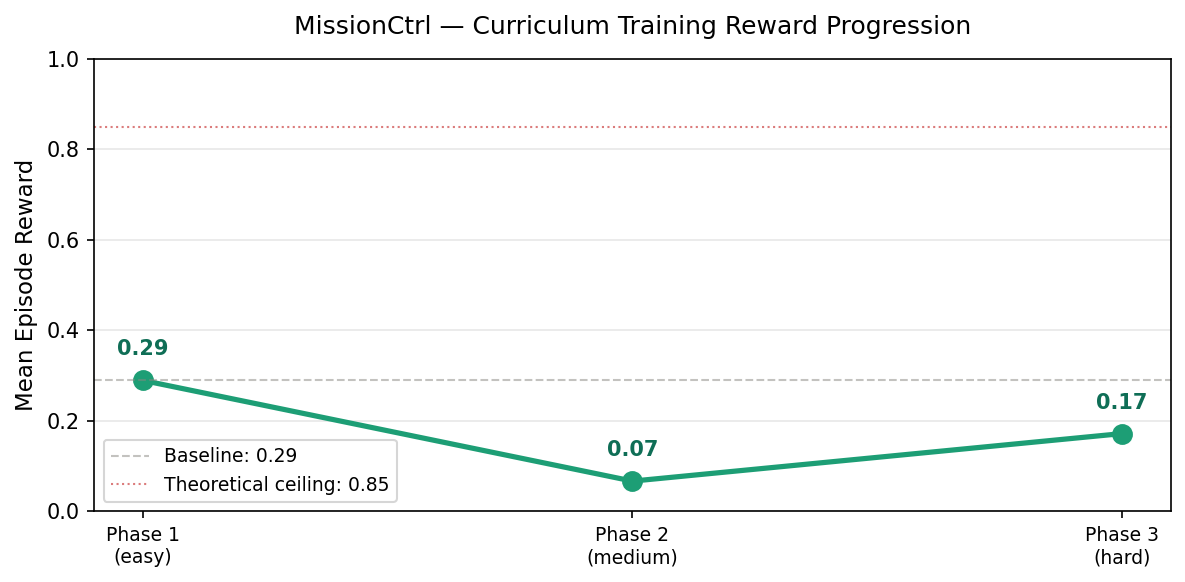

In [11]:
# ── Display reward curve ────────────────────────────────────────────────────────
# FIX #5: curve shows 0.85 ceiling line (not 1.0)
# FIX #12: plot_reward_curve() no longer crashes on empty history
import os
from IPython.display import Image, display

import train
curve_path = os.path.join(train.OUTPUT_DIR, 'reward_curve.png')

if os.path.exists(curve_path):
    print(f"📈 Displaying reward curve from: {curve_path}")
    display(Image(curve_path))
else:
    print('⚠️  Reward curve not found at expected path.')
    print(f'   Checked: {curve_path}')
    for fallback in [
        './missionctrl_checkpoints/reward_curve.png',
        '/content/missionctrl_checkpoints/reward_curve.png',
        '/content/drive/MyDrive/missionctrl_checkpoints/reward_curve.png',
    ]:
        if os.path.exists(fallback):
            print(f'   Found at: {fallback}')
            display(Image(fallback))
            break
    else:
        print('   No reward curve found. Training may not have produced one.')
        print('   Check train.py plot_reward_curve() output.')


In [15]:
# ── Reward breakdown for a single episode ────────────────────────────────────────
from environment import MissionCtrlEnv
from reward_model import reward_breakdown
from train import build_user_prompt, SYSTEM_PROMPT, EPISODE_MAX_STEPS
from environment import parse_action
import torch

debug_env = MissionCtrlEnv(difficulty='hard', num_tasks=4, seed=42)
obs, _ = debug_env.reset()

done = False
steps = 0
while not done and steps < EPISODE_MAX_STEPS:
    prompt_text = tokenizer.apply_chat_template(
        [{'role': 'system', 'content': SYSTEM_PROMPT},
         {'role': 'user',   'content': build_user_prompt(obs)}],
        tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(prompt_text, return_tensors='pt', truncation=True,
                       max_length=3584).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=256, do_sample=False)
    completion = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    action = parse_action(completion)
    obs, _, terminated, truncated, _ = debug_env.step(action)
    done = terminated or truncated
    steps += 1

bd = reward_breakdown(debug_env)
print('=== REWARD BREAKDOWN (seed=42, hard, 4 tasks) ===')
print(f'Total reward: {bd["total_reward"]:.4f} ({bd["total_reward"]/0.85*100:.1f}% of ceiling)')
print()
for signal, vals in bd['signals'].items():
    bar = '█' * int(vals['raw'] * 20)
    print(f'  {signal:<28} raw={vals["raw"]:.3f} [{bar:<20}] weighted={vals["weighted"]:+.4f}')
print()
print(f'Episode info: {bd["info"]}')


=== REWARD BREAKDOWN (seed=42, hard, 4 tasks) ===
Total reward: 0.0097 (1.1% of ceiling)

  task_completion              raw=0.000 [                    ] weighted=+0.0000
  hallucination_detection      raw=0.000 [                    ] weighted=+0.0000
  false_positive_penalty       raw=0.400 [████████            ] weighted=-0.0600
  delegation_efficiency        raw=0.383 [███████             ] weighted=+0.0575
  llm_judge                    raw=0.122 [██                  ] weighted=+0.0123

Episode info: {'injected_hallucinations': 2, 'caught_hallucinations': 0, 'false_positives': 0, 'tasks_done': 0}


## Troubleshooting & FAQ (Colab)

**CUDA out of memory**  
Reduce `BATCH_SIZE` to 2, `MAX_SEQ_LENGTH` to 1024, or use the 0.5B model. For a quick run, set `MISSIONCTRL_SMOKE_STEPS` (see `train.py` / README).

**Session disconnected during training**  
If Drive is mounted (Cell 2), checkpoints survive. Re-run from Cell 8 then Cell 9. Otherwise training starts from scratch.

**No GPU detected**  
Runtime → Change runtime type → T4 GPU → Save → Restart runtime.

**git clone fails**  
Colab needs Internet (default on). You can upload the repo as a zip into `/content` instead.

**HF_TOKEN not found**  
Colab sidebar → key icon → add secret `HF_TOKEN` → enable **Notebook access** → re-run the credentials cell.

**Training is slow on T4**  
Prefer the 0.5B model; Colab Pro (V100/A100) is faster for larger models.

**Resume interrupted training**  
`train.py` looks for checkpoints under `OUTPUT_DIR`. Re-run Cell 9 after Cells 2 and 8 if using Drive.

**bitsandbytes warnings**  
Usually safe. If install errors persist: `!pip install "bitsandbytes>=0.43.0"`
